In [ ]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "32"

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


from ti_3d_ham import (onsite_4x4, hop_4x4, default_params,
                       kron, I2, sx, sy, sz)
import kwant

_S4 = {"x": kron(I2, sx), "y": kron(I2, sy), "z": kron(I2, sz)}

OUT = Path("negf_kwant.py").resolve().parent / "plots"
from negf_kwant import plot_slab_bands, run_negf, sweep_Vdrop, plot_cisp_vs_Vdrop, sweep_EF, plot_cisp_vs_EF

In [ ]:

def main():
    Nz, Nx = 8, 10
    N_ky, N_E = 31, 81
    T = 300
    params = default_params
    common = dict(Nz=Nz, Nx=Nx, N_ky=N_ky, ky_max=0.6,
                  N_E=N_E, params=params, T=T, n_surf=1, eta=5e-4)

    print("=" * 60)
    print("NEGF 3D TI — CISP simulation (kwant self-energies)")
    print("=" * 60)

    # 1. Slab band structure
    print("\n--- Slab band structure ---")
    plot_slab_bands(Nz=Nz, params=params)

    # 2. Single-point test
    print("\n--- Single-point test (E_F=0.1, V_drop=0.05) ---")
    t0 = time.time()
    s = run_negf(0.1, 0.05, **common)
    print(f"  Sx={s['x']:.4e}  Sy={s['y']:.4e}  Sz={s['z']:.4e}")
    print(f"  Time: {time.time() - t0:.1f}s")

    # # 3. CISP vs V_drop
    # print("\n--- CISP vs V_drop ---")
    # V_vals = np.array([0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12])
    # t0 = time.time()
    # cisp_V = sweep_Vdrop(V_vals, E_F=0.1, **common)
    # print(f"  Total time: {time.time() - t0:.1f}s")
    # plot_cisp_vs_Vdrop(V_vals, cisp_V, 0.1, Nz, Nx)

    # 4. CISP vs E_F
    print("\n--- CISP vs E_F ---")
    EF_vals = np.linspace(-0.2, 0.2, 11)
    t0 = time.time()
    cisp_EF = sweep_EF(EF_vals, V_drop=0.001, **common)
    print(f"  Total time: {time.time() - t0:.1f}s")
    plot_cisp_vs_EF(EF_vals, cisp_EF, 0.001, Nz, Nx)

    print("\nDone!")


if __name__ == "__main__":
    main()


NEGF 3D TI — CISP simulation (kwant self-energies)

--- Slab band structure ---
Saved: /home/nandan_diwan/Desktop/hexagonal_warping/NEGF/plots/slab_bands.png

--- Single-point test (E_F=0.1, V_drop=0.05) ---
  ky 1/31  Sy_cum=7.8067e-06
  ky 6/31  Sy_cum=3.4295e-05
  ky 11/31  Sy_cum=8.6434e-05
  ky 16/31  Sy_cum=1.6894e-04
  ky 21/31  Sy_cum=2.3636e-04
  ky 26/31  Sy_cum=2.8889e-04
  ky 31/31  Sy_cum=3.1551e-04
  Sx=-3.6926e-16  Sy=3.1551e-04  Sz=-1.2164e-15
  Time: 34.7s

--- CISP vs E_F ---
E_F=-0.200 (1/11)...
  Sx=-2.711e-16  Sy=-2.634e-05  Sz=2.086e-15
E_F=-0.160 (2/11)...
  Sx=-3.404e-16  Sy=1.027e-04  Sz=3.993e-15
E_F=-0.120 (3/11)...
  Sx=-1.218e-15  Sy=1.624e-04  Sz=2.898e-15
E_F=-0.080 (4/11)...
  Sx=-8.865e-16  Sy=1.974e-04  Sz=8.534e-15
E_F=-0.040 (5/11)...
  Sx=-7.771e-16  Sy=2.296e-04  Sz=2.782e-15
E_F=0.000 (6/11)...
  Sx=-1.146e-15  Sy=2.477e-04  Sz=1.195e-14
E_F=0.040 (7/11)...
  Sx=-1.834e-16  Sy=2.659e-04  Sz=-5.384e-15
E_F=0.080 (8/11)...
  Sx=-8.768e-16  Sy=2.980e

In [1]:
import os
for v in ('OMP_NUM_THREADS','MKL_NUM_THREADS','OPENBLAS_NUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '32'

import sys, time; sys.path.insert(0, 'NEGF')
from negf_kwant import run_negf, run_negf_floquet, default_params
import numpy as np

common = dict(Nz=8, Nx=10, N_ky=31, ky_max=0.6, N_E=81, T=300, n_surf=1, eta=5e-4)

# Scalar potential (old way)
t0 = time.time()
s1 = run_negf(0.1, 0.05, verbose=False, **common)
print(f'Scalar V_drop:  Sy={s1["y"]:.4e}  ({time.time()-t0:.0f}s)')

# Floquet (PH-symmetric)
t0 = time.time()
s2 = run_negf_floquet(0.1, 0.05, omega=0.01, N_F=1, verbose=False, **common)
print(f'Floquet:        Sy={s2["y"]:.4e}  ({time.time()-t0:.0f}s)')

# Check PH: Floquet at +E_F and -E_F
t0 = time.time()
sp = run_negf_floquet(0.1, 0.05, omega=0.01, N_F=1, verbose=False, **common)
sm = run_negf_floquet(-0.1, 0.05, omega=0.01, N_F=1, verbose=False, **common)
s0 = run_negf_floquet(0.0, 0.05, omega=0.01, N_F=1, verbose=False, **common)
seq_p = run_negf_floquet(0.1, 0.0, omega=0.01, N_F=1, verbose=False, **common)
seq_m = run_negf_floquet(-0.1, 0.0, omega=0.01, N_F=1, verbose=False, **common)
seq_0 = run_negf_floquet(0.0, 0.0, omega=0.01, N_F=1, verbose=False, **common)
cisp_p = sp['y'] - seq_p['y']
cisp_m = sm['y'] - seq_m['y']
cisp_0 = s0['y'] - seq_0['y']
print(f'Floquet CISP(+0.1)={cisp_p:.4e}')
print(f'Floquet CISP(-0.1)={cisp_m:.4e}')
print(f'Floquet CISP(0.0) ={cisp_0:.4e}')
print(f'Even check: CISP(+)+CISP(-)={cisp_p+cisp_m:.4e} vs 2*CISP(0)={2*cisp_0:.4e}')
print(f'Time: {time.time()-t0:.0f}s')

Scalar V_drop:  Sy=3.1551e-04  (34s)
Floquet:        Sy=6.5793e-15  (136s)
Floquet CISP(+0.1)=1.1346e-14
Floquet CISP(-0.1)=-5.4471e-17
Floquet CISP(0.0) =7.7384e-15
Even check: CISP(+)+CISP(-)=1.1292e-14 vs 2*CISP(0)=1.5477e-14
Time: 820s


In [6]:
sp

{'x': np.float64(-5.243853921509285e-16),
 'y': np.float64(6.579282231074795e-15),
 'z': np.float64(8.995968162968792e-15)}

In [3]:
sm

{'x': np.float64(-9.92051340571341e-17),
 'y': np.float64(2.127427562712865e-15),
 'z': np.float64(-2.4576047340309915e-15)}

In [7]:
seq_m

{'x': np.float64(1.3398887290837696e-16),
 'y': np.float64(2.1818983121565407e-15),
 'z': np.float64(-6.1866808541584105e-15)}

In [8]:
seq_0

{'x': np.float64(-7.727104648139454e-16),
 'y': np.float64(-3.891915681608271e-15),
 'z': np.float64(-1.6803092656950437e-14)}

In [ ]:
import os
for v in ('OMP_NUM_THREADS','MKL_NUM_THREADS','OPENBLAS_NUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '16'

import sys, time; sys.path.insert(0, 'NEGF')
import numpy as np
from negf_kwant import run_kubo, default_params, sweep_EF_kubo

common = dict(Nz=8, Nx=10, N_ky=31, ky_max=0.6, N_E=81, T=300, n_surf=1, eta=5e-4)

t0 = time.time()
sp = run_kubo(0.15, V_drop=0.05, verbose=False, **common)
sm = run_kubo(-0.15, V_drop=0.05, verbose=False, **common)
s0 = run_kubo(0.0, V_drop=0.05, verbose=False, **common)

print(f'E_F=+0.15: Sy={sp["y"]:.4e}  G={sp["G"]:.4e}  Sy/G={sp["y"]/sp["G"]:.4e}')
print(f'E_F=-0.15: Sy={sm["y"]:.4e}  G={sm["G"]:.4e}  Sy/G={sm["y"]/sm["G"]:.4e}')
print(f'E_F= 0.00: Sy={s0["y"]:.4e}  G={s0["G"]:.4e}  Sy/G={s0["y"]/s0["G"]:.4e}')
print()
print(f'Sy ratio (+/-):  {sp["y"]/sm["y"]:.6f}  (should be -1)')
print(f'G  ratio (+/-):  {sp["G"]/sm["G"]:.6f}  (should be +1)')
print(f'Sy/G ratio (+/-): {(sp["y"]/sp["G"])/(sm["y"]/sm["G"]):.6f}  (should be +1)')
print(f'Time: {time.time()-t0:.0f}s')

E_F=+0.15: Sy=-8.3551e-05  G=4.7951e-02  Sy/G=-1.7424e-03
E_F=-0.15: Sy=8.3551e-05  G=4.7951e-02  Sy/G=1.7424e-03
E_F= 0.00: Sy=1.5307e-18  G=1.2467e-03  Sy/G=1.2277e-15

Sy ratio (+/-):  -1.000000  (should be -1)
G  ratio (+/-):  1.000000  (should be +1)
Sy/G ratio (+/-): -1.000000  (should be +1)
Time: 132s


In [1]:
import os
for v in ('OMP_NUM_THREADS','MKL_NUM_THREADS','OPENBLAS_NUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '16'

import sys, time; sys.path.insert(0, 'NEGF')
import numpy as np
from negf_kwant import run_kubo, default_params, sweep_EF_kubo

common = dict(Nz=8, Nx=10, N_ky=31, ky_max=0.6, N_E=81, T=300, n_surf=1, eta=5e-4)

Ef =  np.linspace(-0.25, 0.25, 11)
results, g_vals =  sweep_EF_kubo(Ef, 0.01, True, **common)

E_F=-0.250 (1/11)...
  Sy=-2.171e-04  G=1.412e-01  Sy/G=-1.537e-03
E_F=-0.200 (2/11)...
  Sy=2.921e-05  G=8.916e-02  Sy/G=3.276e-04
E_F=-0.150 (3/11)...
  Sy=8.355e-05  G=4.795e-02  Sy/G=1.742e-03
E_F=-0.100 (4/11)...
  Sy=5.534e-05  G=1.406e-02  Sy/G=3.936e-03
E_F=-0.050 (5/11)...
  Sy=3.953e-05  G=3.072e-03  Sy/G=1.287e-02
E_F=0.000 (6/11)...
  Sy=1.531e-18  G=1.247e-03  Sy/G=1.228e-15
E_F=0.050 (7/11)...
  Sy=-3.953e-05  G=3.072e-03  Sy/G=-1.287e-02
E_F=0.100 (8/11)...
  Sy=-5.534e-05  G=1.406e-02  Sy/G=-3.936e-03
E_F=0.150 (9/11)...
  Sy=-8.355e-05  G=4.795e-02  Sy/G=-1.742e-03
E_F=0.200 (10/11)...
  Sy=-2.921e-05  G=8.916e-02  Sy/G=-3.276e-04
E_F=0.250 (11/11)...
  Sy=2.171e-04  G=1.412e-01  Sy/G=1.537e-03


In [5]:
import numpy as np
import matplotlib.pyplot as plt
data = np.load("plots/cisp_vs_EF_kubo.npz")


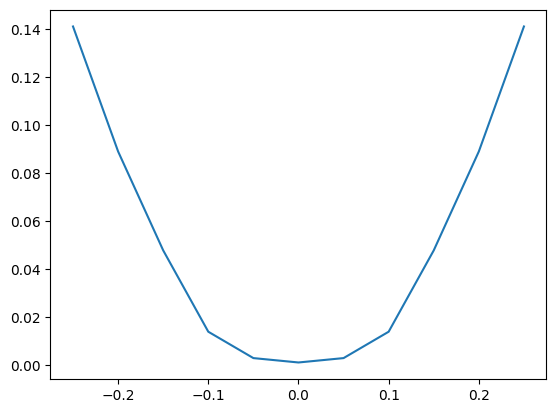

In [7]:
ef = data["EF"]
G = data["G"]
plt.plot(ef, G)
